<a href="https://colab.research.google.com/github/dyjdlopez/intro_2_quantum/blob/main/cuda-q/pythonasia26/cudaq_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QAOA for Max Cut in CUDA-Q
### Variational Quantum Circuits in Practice
**Python Asia 2026** · Dylan Josh Lopez

---

**Prerequisites:** Notebook 1 — or familiarity with `@cudaq.kernel` and `cudaq.sample()`.

By the end of this notebook, you will be able to:

- ✅ Understand the Variational Quantum Circuit (VQC) pattern and how QAOA uses it
- ✅ Formulate the Max Cut problem mathematically and as a QUBO
- ✅ Build and visualise a weighted graph with NetworkX using NVIDIA-style colours
- ✅ Model the problem with **JijModeling** and transpile it to a QUBO/Ising form
- ✅ Solve classically with **OpenJij** Simulated Annealing as a baseline
- ✅ Convert the Ising model to a CUDA-Q Hamiltonian and run QAOA
- ✅ Compare `scipy.optimize.minimize` vs `cudaq-solvers` on speed and quality

---

## Section 0 - Setup

This install is heavier than Notebook 1 — allow ~2 minutes. While it runs we'll walk through the QAOA concept on the slides.

> **Package overview:**
> - `jijmodeling` : symbolic mathematical modelling language (Jij Inc.)
> - `jijmodeling-transpiler` : compiles JijModeling problems to QUBO/Ising dictionaries
> - `openjij`: Ising / QUBO solver with Simulated Annealing; our classical baseline
> - `cudaq` + `cudaq-solvers` : quantum execution and VQE/QAOA solvers
> - `qamomile[cudaq]` : Jij Inc. bridge that turns a JijModeling problem straight into a `@cudaq.kernel`

In [1]:
!pip install cudaq

In [2]:
!pip install cudaq-solvers==0.3.0

In [3]:
!pip install jijmodeling jijmodeling-transpiler openjij ommx-openjij-adapter
!pip install "qamomile[cudaq]"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bloqade-analog 0.16.9 requires numpy>=2.1.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatibl

  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openjij 0.11.6 requires numpy<2.4.0,>=1.19.3, but you have numpy 2.4.3 which is incompatible.
jijmodeling-transpiler 0.7.3 requires numpy<1.27.0,>=1.17.0, but you have numpy 2.4.3 which is incompatible.
jij-cimod 1.7.3 requires numpy<2.4,>=1.19.3, but you have numpy 2.4.3 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which 

In [1]:
import cudaq
import cudaq_solvers as solvers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import time

np.random.seed(42)
cudaq.set_random_seed(42)

print('CUDA-Q version :', cudaq.__version__)
print('NetworkX version:', nx.__version__)
print('Ready!')

CUDA-Q version : CUDA-Q Version 0.11.0 (https://github.com/NVIDIA/cuda-quantum f5cc3bb1d85abcf1f642f4ddd20ad08bc1d4d200)
NetworkX version: 3.6.1
Ready!


---
## Section 1 - Variational Quantum Circuits and QAOA

### 1.1 What is a Variational Quantum Circuit (VQC)?

A **Variational Quantum Circuit (VQC)** is a quantum circuit with tunable rotation angles — think of it as a quantum neural network where *angles* play the role of *weights*.

$$|\psi(\boldsymbol{\theta})\rangle = U(\boldsymbol{\theta})|0\rangle$$

The circuit prepares a quantum state that depends on the parameter vector $\boldsymbol{\theta}$. A classical optimiser iteratively adjusts $\boldsymbol{\theta}$ to minimise a cost function — the **expectation value** of a Hamiltonian $H$:

$$C(\boldsymbol{\theta}) = \langle\psi(\boldsymbol{\theta})|H|\psi(\boldsymbol{\theta})\rangle$$

This hybrid loop — quantum state preparation + classical parameter update — is the core of all **Variational Quantum Algorithms (VQAs)**, including QAOA and VQE.

![VQC Loop](https://www.catalyzex.com/_next/image?url=https%3A%2F%2Fai2-s2-public.s3.amazonaws.com%2Ffigures%2F2017-08-08%2Ff0f0fcf6206a13f1eb5684f8cfed2844ac74fc9f%2F2-Figure1-1.png&w=640&q=75)

*Figure: The hybrid quantum-classical variational loop. Source: Cerezo, M., Arrasmith, A., Babbush, R. et al. Variational quantum algorithms. Nat Rev Phys 3, 625–644 (2021)*

### 1.2 — QAOA: The Quantum Approximate Optimization Algorithm

**QAOA** (Farhi, Goldstone & Gutmann, 2014) is a VQA designed specifically for **combinatorial optimisation**. It alternates between two quantum operators for $p$ layers:

| Layer | Operator | Purpose |
|---|---|---|
| Cost layer | $U_C(\gamma) = e^{-i\gamma H_C}$ | Encodes the problem - penalises bad solutions |
| Mixer layer | $U_M(\beta) = e^{-i\beta H_M}$ | Explores the search space - prevents getting stuck |

The full QAOA state is:
$$|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle = U_M(\beta_p)U_C(\gamma_p) \cdots U_M(\beta_1)U_C(\gamma_1)|+\rangle^{\otimes n}$$

Deeper circuits (higher $p$) give better approximations, at the cost of more parameters to optimise.

![QAOA](https://nvidia.github.io/cuda-quantum/latest/_images/qaoa-circuit-layers.png)

*Figure: QAOA Circuit. Source: NVIDIA CUDA-Q Max-Cut with QAOA*

> **`cudaq_solvers.qaoa()`** packages this entire loop — quantum circuit + classical optimiser + sampling — into a single Python call. That's the payoff for everything we build in this notebook.

---
## Section 2 - The Max Cut Problem

### 2.1 Problem Definition

Given an undirected weighted graph $G = (V, E, w)$, the **Max Cut** problem asks:

> *Partition the nodes $V$ into two sets $S$ and $\bar{S}$ to maximise the total weight of edges that cross the partition.*

$$\text{Max Cut}(S) = \sum_{(i,j) \in E} w_{ij} \cdot \mathbf{1}[i \in S, j \notin S]$$

It is **NP-hard** for general weighted graphs. Classical brute-force search requires checking $2^{|V|}$ partitions. For 50 nodes that is over $10^{15}$ combinations.

![Max Cut Illustration](https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/Max-cut.svg/500px-Max-cut.svg.png)

*Figure: A Max Cut partition. Dashed edges cross the cut. Source: Wikimedia Commons, CC BY-SA 3.0*

### 2.2 Binary Variable Formulation

Assign each node $i$ a binary variable:
$$x_i = \begin{cases} 1 & \text{if node } i \in S \\ 0 & \text{if node } i \in \bar{S} \end{cases}$$

An edge $(i, j)$ is **cut** when $x_i \neq x_j$, which happens when $x_i + x_j - 2x_ix_j = 1$. So the objective to **maximise** is:

$$\text{Cut}(x) = \sum_{(i,j) \in E} w_{ij}(x_i + x_j - 2x_ix_j)$$

### 2.3 QUBO Formulation (for minimisation)

Since optimisers minimise, we flip the sign:

$$\min_{x \in \{0,1\}^n} \; -\sum_{(i,j) \in E} w_{ij}(x_i + x_j - 2x_ix_j)$$

This is a **Quadratic Unconstrained Binary Optimisation (QUBO)** problem — no constraints, binary variables, degree-2 objective. It maps directly to an Ising Hamiltonian, which maps directly to a quantum circuit.

### 2.4 - Quantum Hamiltonian

Using the substitution $x_i = (1 - Z_i)/2$ (where $Z_i$ is the Pauli-Z operator on qubit $i$), the Max Cut Hamiltonian becomes:

$$H_C = \frac{1}{2}\sum_{(i,j) \in E} w_{ij}(I - Z_iZ_j)$$

Maximising cut weight $\Leftrightarrow$ finding the **ground state** (minimum eigenvalue) of $-H_C$. This is what QAOA finds.

---
## Section 3 - Building the Graph with NetworkX

### 3.1 - Creating a Weighted Graph

We'll work with a 5-node weighted graph — small enough to verify by brute force, large enough to illustrate the algorithm.

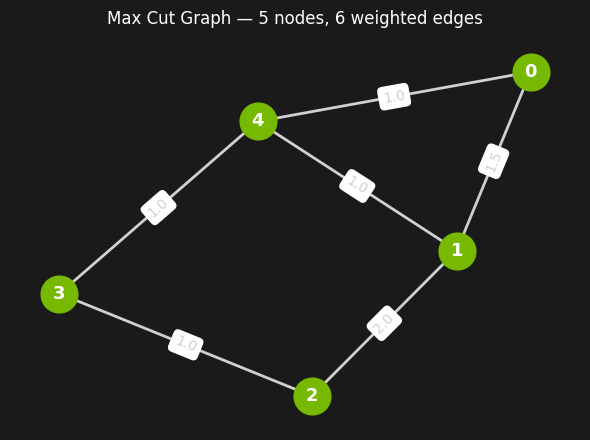

Nodes : [0, 1, 2, 4, 3]
Edges : [(0, 1, 1.5), (0, 4, 1.0), (1, 2, 2.0), (1, 4, 1.0), (2, 3, 1.0), (4, 3, 1.0)]


In [2]:
# NVIDIA colour palette
NVIDIA_GREEN = '#76B900'
NVIDIA_DARK = '#1A1A1A'
NVIDIA_BLUE = '#00A3E0'
NVIDIA_VIOLET = '#6D4D8E'
NVIDIA_SILVER = '#D0D0D0'
CUT_RED = '#E24B4A'

# Build weighted graph
G = nx.Graph()
G.add_weighted_edges_from([
    (0, 1, 1.5),
    (1, 2, 2.0),
    (1, 4, 1.0),
    (2, 3, 1.0),
    (3, 4, 1.0),
    (4, 0, 1.0),
])

pos = nx.spring_layout(G, seed=42)
edge_labels = {(u, v): f"{d['weight']}" for u, v, d in G.edges(data=True)}
num_nodes = G.number_of_nodes()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.set_facecolor(NVIDIA_DARK)
fig.patch.set_facecolor(NVIDIA_DARK)

nx.draw_networkx_nodes(G, pos, node_color=NVIDIA_GREEN, node_size=700, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', font_size=13, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color=NVIDIA_SILVER, width=2.0, ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_color=NVIDIA_SILVER, font_size=10, ax=ax)

ax.set_title('Max Cut Graph — 5 nodes, 6 weighted edges', color='white', fontsize=12, pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Nodes : {list(G.nodes)}')
print(f'Edges : {[(u, v, d["weight"]) for u, v, d in G.edges(data=True)]}')

### 3.2 - Classical Brute Force Baseline

Before running QAOA, let's compute the **ground truth** by checking all $2^5 = 32$ partitions. This is the answer QAOA needs to match — and exactly what becomes intractable at scale.

Brute-force best cut weight : 6.5
Partition (0=set A, 1=set B): {0: 0, 1: 1, 2: 0, 3: 1, 4: 0}


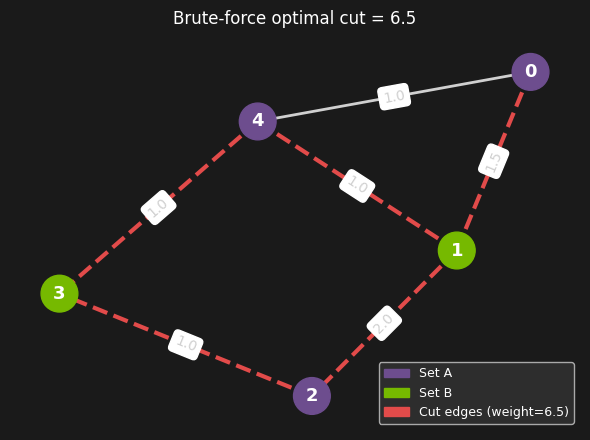

In [3]:
def brute_force_max_cut(G):
    n = G.number_of_nodes()
    best_cut, best_partition = 0, None
    for mask in range(2**n):
        cut = sum(
            d['weight']
            for u, v, d in G.edges(data=True)
            if ((mask >> u) & 1) != ((mask >> v) & 1)
        )
        if cut > best_cut:
            best_cut = cut
            best_partition = mask
    partition = {i: (best_partition >> i) & 1 for i in range(n)}
    return best_cut, partition

best_cut_bf, best_partition_bf = brute_force_max_cut(G)
print(f'Brute-force best cut weight : {best_cut_bf}')
print(f'Partition (0=set A, 1=set B): {best_partition_bf}')

# Visualise the brute-force solution
colors = [NVIDIA_VIOLET if best_partition_bf[i] == 0 else NVIDIA_GREEN for i in G.nodes]
cut_edges    = [(u, v) for u, v in G.edges() if best_partition_bf[u] != best_partition_bf[v]]
noncut_edges = [(u, v) for u, v in G.edges() if best_partition_bf[u] == best_partition_bf[v]]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.set_facecolor(NVIDIA_DARK)
fig.patch.set_facecolor(NVIDIA_DARK)

nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=700, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', font_size=13, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=noncut_edges, edge_color=NVIDIA_SILVER, width=2.0, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, edge_color=CUT_RED,
                        width=3.0, style='dashed', ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_color=NVIDIA_SILVER, font_size=10, ax=ax)

violet_patch  = mpatches.Patch(color=NVIDIA_VIOLET,  label='Set A')
green_patch = mpatches.Patch(color=NVIDIA_GREEN, label='Set B')
red_patch   = mpatches.Patch(color=CUT_RED,      label=f'Cut edges (weight={best_cut_bf})')
ax.legend(handles=[violet_patch, green_patch, red_patch],
          loc='lower right', facecolor='#333', labelcolor='white', fontsize=9)

ax.set_title(f'Brute-force optimal cut = {best_cut_bf}', color='white', fontsize=12, pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Section 4 - Modelling the Hamiltonian with JijModeling

### 4.1 - What is QUBO?

**QUBO** = Quadratic Unconstrained Binary Optimisation. Any combinatorial problem expressible with binary variables and a degree-2 objective is a QUBO:

$$\min_{x \in \{0,1\}^n} \; x^T Q x = \sum_{i} Q_{ii}x_i + \sum_{i < j} Q_{ij}x_i x_j$$

| Term | Meaning |
|---|---|
| $Q_{ii}$ | Linear penalty/reward on variable $i$ |
| $Q_{ij}$ ($i < j$) | Quadratic interaction between variables $i$ and $j$ |

### 4.2 - What is the Ising Model?

QUBO variables live in $\{0, 1\}$. Quantum computers prefer **spin variables** $s_i \in \{-1, +1\}$ via the substitution $x_i = (1 - s_i)/2$.

After this change of variables, QUBO becomes the **Ising model**:

$$H_{\text{Ising}} = \sum_i h_i s_i + \sum_{i < j} J_{ij} s_i s_j$$

where $h_i$ are linear (magnetic field) terms and $J_{ij}$ are quadratic (spin coupling) terms. In CUDA-Q, $s_i$ becomes the Pauli-Z operator on qubit $i$.

```
  JijModeling problem
        │
        ▼  jijmodeling-transpiler
  QUBO dict  {(i,j): coeff}
        │
        ├──▶  openjij SASampler        (classical Simulated Annealing baseline)
        │
        └──▶  to_cudaq() / Qamomile    (→ cudaq.SpinOperator + @cudaq.kernel)
```

### 4.3 - Define the Problem with JijModeling

**JijModeling** is a symbolic modelling language — you write the mathematical formulation directly in Python, like a clean textbook expression. `jijmodeling-transpiler` then compiles it to a QUBO/Ising dictionary that any solver can consume.

In [4]:
import jijmodeling as jm
import jijmodeling_transpiler as jmt

V = jm.Placeholder("V")
E = jm.Placeholder("E", ndim=2)
x = jm.BinaryVar("x", shape=(V,))
e = jm.Element("e", belong_to=E)
i = jm.Element("i", belong_to=V)
j = jm.Element("j", belong_to=V)

problem = jm.Problem("Maxcut", sense=jm.ProblemSense.MAXIMIZE)
si = 2 * x[e[0]] - 1
sj = 2 * x[e[1]] - 1
si.set_latex("s_{e[0]}")
sj.set_latex("s_{e[1]}")
obj = 1 / 2 * jm.sum(e, (1 - si * sj))
problem += obj
problem

In [5]:
data = {'V': num_nodes, 'E': [[u, v] for u, v in G.edges()]}
data

{'V': 5, 'E': [[0, 1], [0, 4], [1, 2], [1, 4], [2, 3], [4, 3]]}

In [6]:
interpreter = jm.Interpreter(data)
compiled_model = interpreter.eval_problem(problem)

In [7]:
jmt_compiled = jmt.core.compile_model(problem, data, {})

# transpile_to_pubo returns a PuboBuilder (NOT a tuple)
pubo_builder = jmt.core.pubo.transpile_to_pubo(
    compiled_model=jmt_compiled,
    relax_method=jmt.core.pubo.RelaxationMethod.AugmentedLagrangian
)

# get_qubo_dict returns a (dict, constant) tuple from the builder
qubo_dict, qubo_const = pubo_builder.get_qubo_dict(multipliers={})

print(f'\nQUBO compiled  —  {len(qubo_dict)} terms,  offset = {qubo_const:.4f}')
for k, v in list(qubo_dict.items())[:5]:
    print(f'  Q{k} = {float(v):.4f}')


QUBO compiled  —  11 terms,  offset = 0.0000
  Q(1, 1) = -1.0000
  Q(0, 0) = -0.6667
  Q(0, 1) = 0.6667
  Q(2, 2) = -1.0000
  Q(0, 2) = 0.6667


### 4.4 - Classical Baseline: OpenJij Simulated Annealing

Before touching quantum, let's solve the same QUBO with **OpenJij's Simulated Annealing** sampler. This gives us a fast classical reference to compare QAOA against.

OpenJij's `SASampler` accepts the QUBO dictionary directly from `jijmodeling-transpiler` — no conversion needed.

In [8]:
import openjij as oj

# OpenJij Simulated Annealing
t0_sa    = time.time()
sampler  = oj.SASampler()
response = sampler.sample_qubo(qubo_dict, num_reads=2048)
t1_sa    = time.time()
sa_time  = t1_sa - t0_sa

# decode_from_openjij needs jmt_compiled, not compiled_model (OMMX instance)
sa_sampleset = jmt.core.pubo.decode_from_openjij(response, pubo_builder, jmt_compiled)
sa_best_raw  = response.first.sample  # {var_index: 0/1}

# Map back to graph partition and compute cut value
sa_partition = {idx: int(sa_best_raw[idx]) for idx in range(num_nodes)}
sa_cut = sum(d['weight'] for u, v, d in G.edges(data=True)
             if sa_partition[u] != sa_partition[v])

print('OpenJij Simulated Annealing')
print(f'  Best cut weight : {sa_cut:.2f}')
print(f'  Partition       : {sa_partition}')
print(f'  Wall time       : {sa_time:.3f} s')


OpenJij Simulated Annealing
  Best cut weight : 3.00
  Partition       : {0: 0, 1: 0, 2: 1, 3: 1, 4: 0}
  Wall time       : 0.631 s


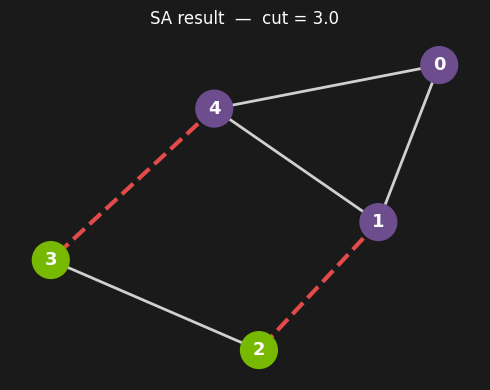

In [9]:
sa_cut_edges    = [(u, v) for u, v in G.edges() if sa_partition[u] != sa_partition[v]]
sa_noncut_edges = [(u, v) for u, v in G.edges() if sa_partition[u] == sa_partition[v]]
sa_colors       = [NVIDIA_VIOLET if sa_partition[i] == 0 else NVIDIA_GREEN for i in G.nodes()]

fig, ax = plt.subplots(figsize=(5, 4))
ax.set_facecolor(NVIDIA_DARK)
fig.patch.set_facecolor(NVIDIA_DARK)

nx.draw_networkx_nodes(G, pos, node_color=sa_colors, node_size=700, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', font_size=13, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=sa_noncut_edges, edge_color=NVIDIA_SILVER, width=2.0, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=sa_cut_edges, edge_color=CUT_RED, width=3.0, style='dashed', ax=ax)

ax.set_title(f'SA result  —  cut = {sa_cut:.1f}', color='white', fontsize=12, pad=8)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Section 5 - Converting to QAOA with Qamomile

### 5.1 - What is Qamomile?

**Qamomile** (Jij Inc., 2025) is a cross-SDK bridge that takes a compiled JijModeling instance and generates a ready-to-run QAOA circuit for any supported backend — including CUDA-Q — without writing the `QAOAConverter` boilerplate manually.

```
  jijmodeling problem  ──compile──▶  compiled_instance
                                            │
                                  QAOAConverter  (qamomile core)
                                            │
                                  CUDAQTranspiler  (qamomile[cudaq])
                                            │
                                  @cudaq.kernel + SpinOperator
```

This is the **recommended production path** — problem formulation stays in JijModeling, circuit generation in Qamomile, execution in CUDA-Q.

### 5.2 - Transpile the Compiled Model to a CUDA-Q Circuit

In [10]:
import qamomile.core as qm
from qamomile.cudaq.transpiler import CudaqTranspiler

# compiled_model is the OMMX instance from jm.Interpreter
qaoa_converter = qm.qaoa.QAOAConverter(compiled_model)
qaoa_converter.ising_encode()

qaoa_hamiltonian = qaoa_converter.get_cost_hamiltonian()

num_layers = 2
qaoa_circuit = qaoa_converter.get_qaoa_ansatz(p=num_layers)

# Transpile to CUDA-Q
transpiler        = CudaqTranspiler()
circ_func         = transpiler.transpile_circuit(qaoa_circuit)
cudaq_hamiltonian = transpiler.transpile_hamiltonian(qaoa_hamiltonian)

num_params = 2 * num_layers
print('Qamomile → CUDA-Q transpilation complete.')
print(f'Layers (p)   : {num_layers}')
print(f'Parameters   : {num_params}  (γ₁, β₁, γ₂, β₂)')
print(f'Hamiltonian  : {cudaq_hamiltonian}')
print()

Qamomile → CUDA-Q transpilation complete.
Layers (p)   : 2
Parameters   : 4  (γ₁, β₁, γ₂, β₂)
Hamiltonian  : (0+0i) + (0.5+0i) * Z0Z1 + (0.5+0i) * Z0Z4 + (0.5+0i) * Z1Z2 + (0.5+0i) * Z1Z4 + (0.5+0i) * Z2Z3 + (0.5+0i) * Z3Z4



### 5.3 - Draw the Generated Circuit

In [11]:
print('Circuit diagram:')
init_params = np.random.uniform(-np.pi / 8, np.pi / 8, num_params)
print(cudaq.draw(circ_func, init_params))

Circuit diagram:
     ╭───╮                                                  ╭────────────╮»
q0 : ┤ h ├──●───────────────────●────●───────────────────●──┤ rx(0.5752) ├»
     ├───┤╭─┴─╮╭─────────────╮╭─┴─╮  │                   │  ╰────────────╯»
q1 : ┤ h ├┤ x ├┤ rz(-0.3471) ├┤ x ├──┼───────────────────┼────────●───────»
     ├───┤╰───╯╰─────────────╯╰───╯  │                   │      ╭─┴─╮     »
q2 : ┤ h ├───────────────────────────┼───────────────────┼──────┤ x ├─────»
     ├───┤                           │                   │      ╰───╯     »
q3 : ┤ h ├───────────────────────────┼───────────────────┼────────────────»
     ├───┤                         ╭─┴─╮╭─────────────╮╭─┴─╮              »
q4 : ┤ h ├─────────────────────────┤ x ├┤ rz(-0.3471) ├┤ x ├──────────────»
     ╰───╯                         ╰───╯╰─────────────╯╰───╯              »

################################################################################

                                                                

---
## Section 6 - Solving: OpenJij SA vs scipy vs cudaq-solvers

We solve the same Max Cut problem with three methods and compare **time** and **solution quality**:

| # | Method | Backend | Notes |
|---|---|---|---|
| A | OpenJij SA | CPU classical | Already done in Section 4 |
| B | `cudaq_solvers.vqe()` | CUDA-Q CPU sim | Managed VQE loop |
| C | `cudaq_solvers.qaoa()` | CUDA-Q CPU sim | Full QAOA in one call |

### 6.1 - Using Scipy as a classical Solver

In [20]:
import cudaq_solvers as solvers
from scipy.optimize import minimize

np.random.seed(42)
initial_parameters = np.random.uniform(-np.pi / 8, np.pi / 8, num_params)

cudaq.set_target('nvidia')  # GPU runtime required

t0_vqe = time.time()
expectation, optimized_parameters, _ = solvers.vqe(
    circ_func,
    cudaq_hamiltonian,
    initial_parameters,
    optimizer=minimize,
    method='L-BFGS-B',
    jac='3-point',
    tol=1e-5,
    options={'disp': True}
)
t1_vqe = time.time()

print(f'Final expectation value : {expectation:.6f}')
print(f'Wall time               : {t1_vqe - t0_vqe:.3f} s')

Final expectation value : -1.495833
Wall time               : 0.466 s


### 6.2 - Method B: cudaq-solvers.qaoa()

In [21]:
num_layers = 2
parameter_count = solvers.get_num_qaoa_parameters(
    cudaq_hamiltonian,
    num_layers,
    full_parameterization=False
)
cudaq.set_target('nvidia')
np.random.seed(42)
initial_parameters = np.random.uniform(-np.pi / 8, np.pi / 8, parameter_count)

t0_qaoa = time.time()
opt_value, opt_params, opt_config = solvers.qaoa(
    cudaq_hamiltonian,
    num_layers,
    initial_parameters,
    optimizer='lbfgs',
    full_parameterization=False,
)
t1_qaoa = time.time()

print(f'Optimal energy       : {opt_value:.6f}')
print(f'Wall time            : {t1_qaoa - t0_qaoa:.3f} s')
print(f'Optimal bitstring    : {opt_config.most_probable()}')
print()

Optimal energy       : -1.623429
Wall time            : 0.100 s
Optimal bitstring    : 10101



### 6.4 - Comparison: Time and Quality

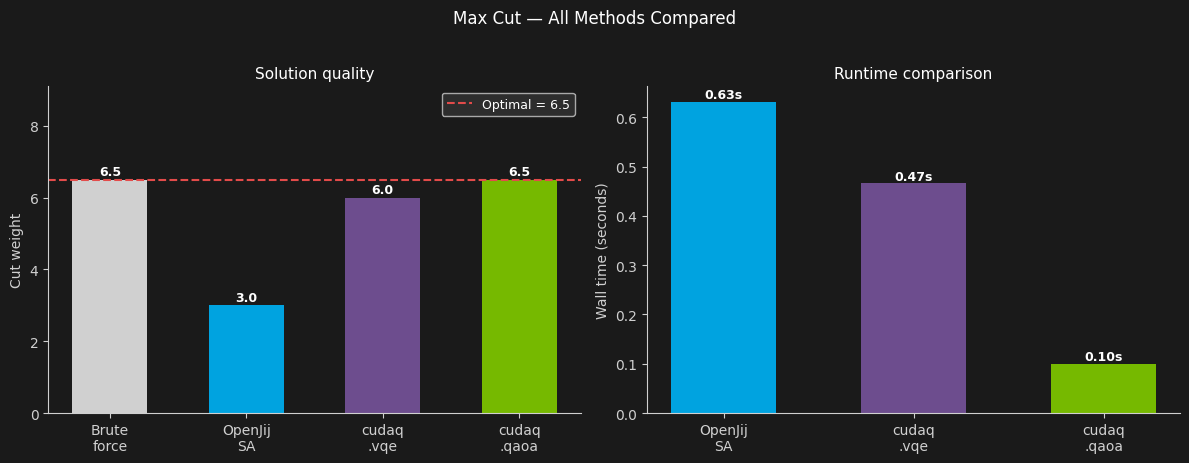

In [22]:
def bitstring_to_cut(G, bits):
    partition = {i: int(bits[i]) for i in range(len(bits))}
    return sum(d['weight'] for u, v, d in G.edges(data=True)
               if partition[u] != partition[v]), partition

# VQE result (circ_func + optimized_parameters from solvers.vqe)
vqe_counts   = cudaq.sample(circ_func, optimized_parameters, shots_count=2048)
vqe_best     = vqe_counts.most_probable()
vqe_cut, _   = bitstring_to_cut(G, vqe_best)

# QAOA result (opt_config from solvers.qaoa)
qaoa_best    = opt_config.most_probable()
qaoa_cut, _  = bitstring_to_cut(G, qaoa_best)

vqe_time  = t1_vqe  - t0_vqe
qaoa_time = t1_qaoa - t0_qaoa

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: cut quality
ax = axes[0]
ax.set_facecolor(NVIDIA_DARK)
fig.patch.set_facecolor(NVIDIA_DARK)
methods = ['Brute\nforce', 'OpenJij\nSA', 'cudaq\n.vqe', 'cudaq\n.qaoa']
cuts    = [best_cut_bf, sa_cut, vqe_cut, qaoa_cut]
colors  = [NVIDIA_SILVER, NVIDIA_BLUE, NVIDIA_VIOLET, NVIDIA_GREEN]
bars = ax.bar(methods, cuts, color=colors, width=0.55, edgecolor='none')
ax.axhline(best_cut_bf, color=CUT_RED, linestyle='--', linewidth=1.5,
           label=f'Optimal = {best_cut_bf}')
ax.set_ylim(0, best_cut_bf * 1.4)
ax.set_ylabel('Cut weight', color=NVIDIA_SILVER)
ax.set_title('Solution quality', color='white', fontsize=11)
ax.tick_params(colors=NVIDIA_SILVER)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax.spines[sp].set_color(NVIDIA_SILVER)
ax.legend(facecolor='#333', labelcolor='white', fontsize=9)
for bar, val in zip(bars, cuts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', va='bottom', color='white',
            fontsize=9, fontweight='bold')

# Right: timing
ax2 = axes[1]
ax2.set_facecolor(NVIDIA_DARK)
t_methods = ['OpenJij\nSA', 'cudaq\n.vqe', 'cudaq\n.qaoa']
t_vals    = [sa_time, vqe_time, qaoa_time]
t_colors  = [NVIDIA_BLUE, NVIDIA_VIOLET, NVIDIA_GREEN]
bars2 = ax2.bar(t_methods, t_vals, color=t_colors, width=0.55, edgecolor='none')
ax2.set_ylabel('Wall time (seconds)', color=NVIDIA_SILVER)
ax2.set_title('Runtime comparison', color='white', fontsize=11)
ax2.tick_params(colors=NVIDIA_SILVER)
for sp in ['top', 'right']: ax2.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax2.spines[sp].set_color(NVIDIA_SILVER)
for bar, val in zip(bars2, t_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.2f}s', ha='center', va='bottom', color='white',
             fontsize=9, fontweight='bold')

plt.suptitle('Max Cut — All Methods Compared',
             color='white', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 6.5 — Visualise the QAOA Solution

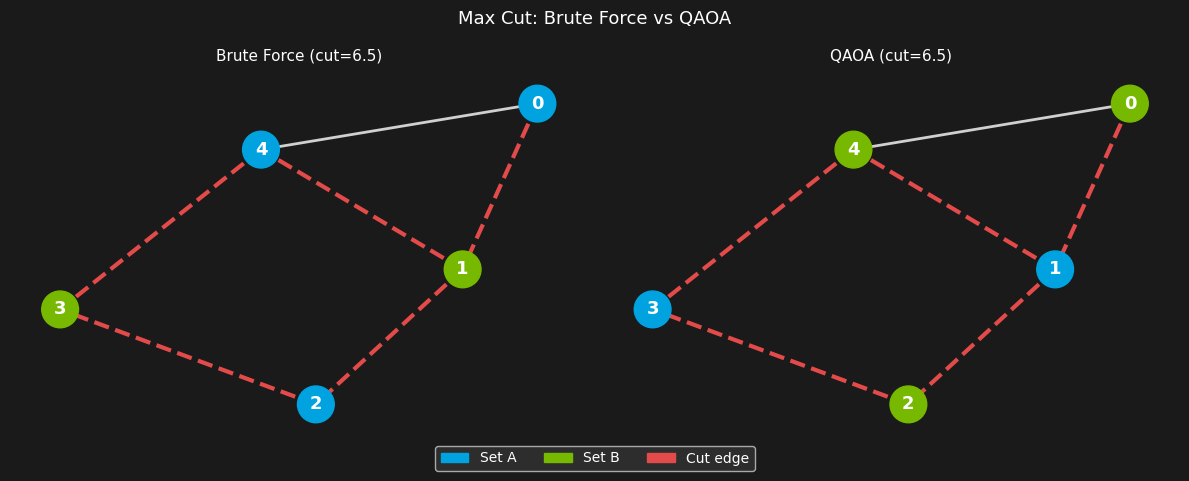

Brute force cut     : 6.50  | partition: {0: 0, 1: 1, 2: 0, 3: 1, 4: 0}
QAOA cut            : 6.50  | partition: {0: 1, 1: 0, 2: 1, 3: 0, 4: 1}
Approximation ratio : 1.000


In [23]:
qaoa_best = opt_config.most_probable()
qaoa_cut, qaoa_partition = bitstring_to_cut(G, qaoa_best)

bf_best        = max(
    [format(m, f'0{num_nodes}b') for m in range(2**num_nodes)],
    key=lambda b: bitstring_to_cut(G, b)[0]
)
best_cut_bf, best_partition = bitstring_to_cut(G, bf_best)

q_colors       = [NVIDIA_BLUE if qaoa_partition[i] == 0 else NVIDIA_GREEN for i in G.nodes()]
q_cut_edges    = [(u, v) for u, v in G.edges() if qaoa_partition[u] != qaoa_partition[v]]
q_noncut_edges = [(u, v) for u, v in G.edges() if qaoa_partition[u] == qaoa_partition[v]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.patch.set_facecolor(NVIDIA_DARK)

for ax, colors_used, cut_e, noncut_e, title in [
    (axes[0],
     [NVIDIA_BLUE if best_partition[i] == 0 else NVIDIA_GREEN for i in G.nodes()],
     [(u, v) for u, v in G.edges() if best_partition[u] != best_partition[v]],
     [(u, v) for u, v in G.edges() if best_partition[u] == best_partition[v]],
     f'Brute Force (cut={best_cut_bf:.1f})'),
    (axes[1], q_colors, q_cut_edges, q_noncut_edges,
     f'QAOA (cut={qaoa_cut:.1f})'),
]:
    ax.set_facecolor(NVIDIA_DARK)
    nx.draw_networkx_nodes(G, pos, node_color=colors_used, node_size=700, ax=ax)
    nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=noncut_e, edge_color=NVIDIA_SILVER, width=2.0, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=cut_e, edge_color=CUT_RED,
                           width=3.0, style='dashed', ax=ax)
    ax.set_title(title, color='white', fontsize=11, pad=8)
    ax.axis('off')

blue_patch  = mpatches.Patch(color=NVIDIA_BLUE,  label='Set A')
green_patch = mpatches.Patch(color=NVIDIA_GREEN, label='Set B')
red_patch   = mpatches.Patch(color=CUT_RED,      label='Cut edge')
fig.legend(handles=[blue_patch, green_patch, red_patch],
           loc='lower center', ncol=3, facecolor='#333', labelcolor='white',
           fontsize=10, bbox_to_anchor=(0.5, -0.06))

plt.suptitle('Max Cut: Brute Force vs QAOA', color='white', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Brute force cut     : {best_cut_bf:.2f}  | partition: {best_partition}')
print(f'QAOA cut            : {qaoa_cut:.2f}  | partition: {qaoa_partition}')
print(f'Approximation ratio : {qaoa_cut / best_cut_bf:.3f}')

---
## Section 7 — Wrap-Up and Next Steps

Here's what we built end-to-end:

| Step | Tool | What it did |
|---|---|---|
| Graph | `networkx` | Defined the Max Cut problem |
| QUBO | `jijmodeling` + `jijmodeling-transpiler` | Symbolic model → QUBO dict |
| Ising → circuit | `to_cudaq()` / `Qamomile` | Binary → spin → quantum Hamiltonian |
| Variational loop | `scipy` + `cudaq.observe()` | Manual optimisation |
| One-liner solver | `cudaq_solvers.qaoa()` | Full QAOA in one call |
| Comparison | `matplotlib` | Time and quality side-by-side |

### Where to go next

- 📦 **CUDA-Q Academic:** [github.com/NVIDIA/cuda-q-academic](https://github.com/NVIDIA/cuda-q-academic) — QAOA-for-Max-Cut module, finance applications, QIS examples
- 🌏 **Qamomile:** [github.com/Jij-Inc/Qamomile](https://github.com/Jij-Inc/Qamomile) — cross-SDK QUBO bridge
- 🔬 **qBraid:** [qbraid.com](https://qbraid.com) — GPU-enabled cloud for CUDA-Q notebooks
- 🇵🇭 **QCSP:** [qcsp.ph](https://qcsp.ph) — Quantum Computing Society of the Philippines

> **Try it yourself:** Fork this notebook. Change the graph. Add a heavier edge. Try `num_layers=3`. Run on the `nvidia` target if you have a GPU. The code doesn't change — only the problem does.

---
$$_{\text{Dylan Josh Lopez | Python Asia 2026}}$$